# Image Classification with Convolutional Neural Networks

## Building a CNN from Scratch for Visual Pattern Recognition

This notebook implements a Convolutional Neural Network (CNN) from first principles, demonstrating the fundamental operations that power modern computer vision: convolution, pooling, and backpropagation through spatial layers. We'll classify handwritten digits using only NumPy - no deep learning frameworks - to build genuine understanding of how CNNs extract and learn visual features.

### What You'll Learn

1. **Convolution Operation**: How sliding filters extract local features from images
2. **Feature Maps**: Visualizing what each convolutional layer detects
3. **Pooling Layers**: Spatial downsampling for translation invariance
4. **Backpropagation**: Computing gradients through convolutional layers
5. **Training Dynamics**: Watching feature detectors emerge during learning

### Mathematical Foundation

The core convolution operation for a single filter:

$$y[i,j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} x[i+m, j+n] \cdot w[m,n] + b$$

where:
- $x$ is the input image (or feature map)
- $w$ is the convolutional filter (kernel)
- $b$ is the bias term
- $k$ is the kernel size

Multiple filters produce multiple feature maps, capturing different visual patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Style configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

print("Computer Vision with CNNs - Educational Implementation")
print("="*55)

Computer Vision with CNNs - Educational Implementation


## 1. Understanding the Convolution Operation

Before building a full CNN, let's understand what convolution does to an image. A convolutional filter (kernel) slides across the image, computing dot products at each position to produce a feature map.

### Key Insight

Different filters detect different features:
- **Edge detectors**: High values where intensity changes rapidly
- **Blob detectors**: High values for circular patterns
- **Texture detectors**: High values for specific spatial patterns

In a CNN, these filters are *learned* from data rather than hand-designed.

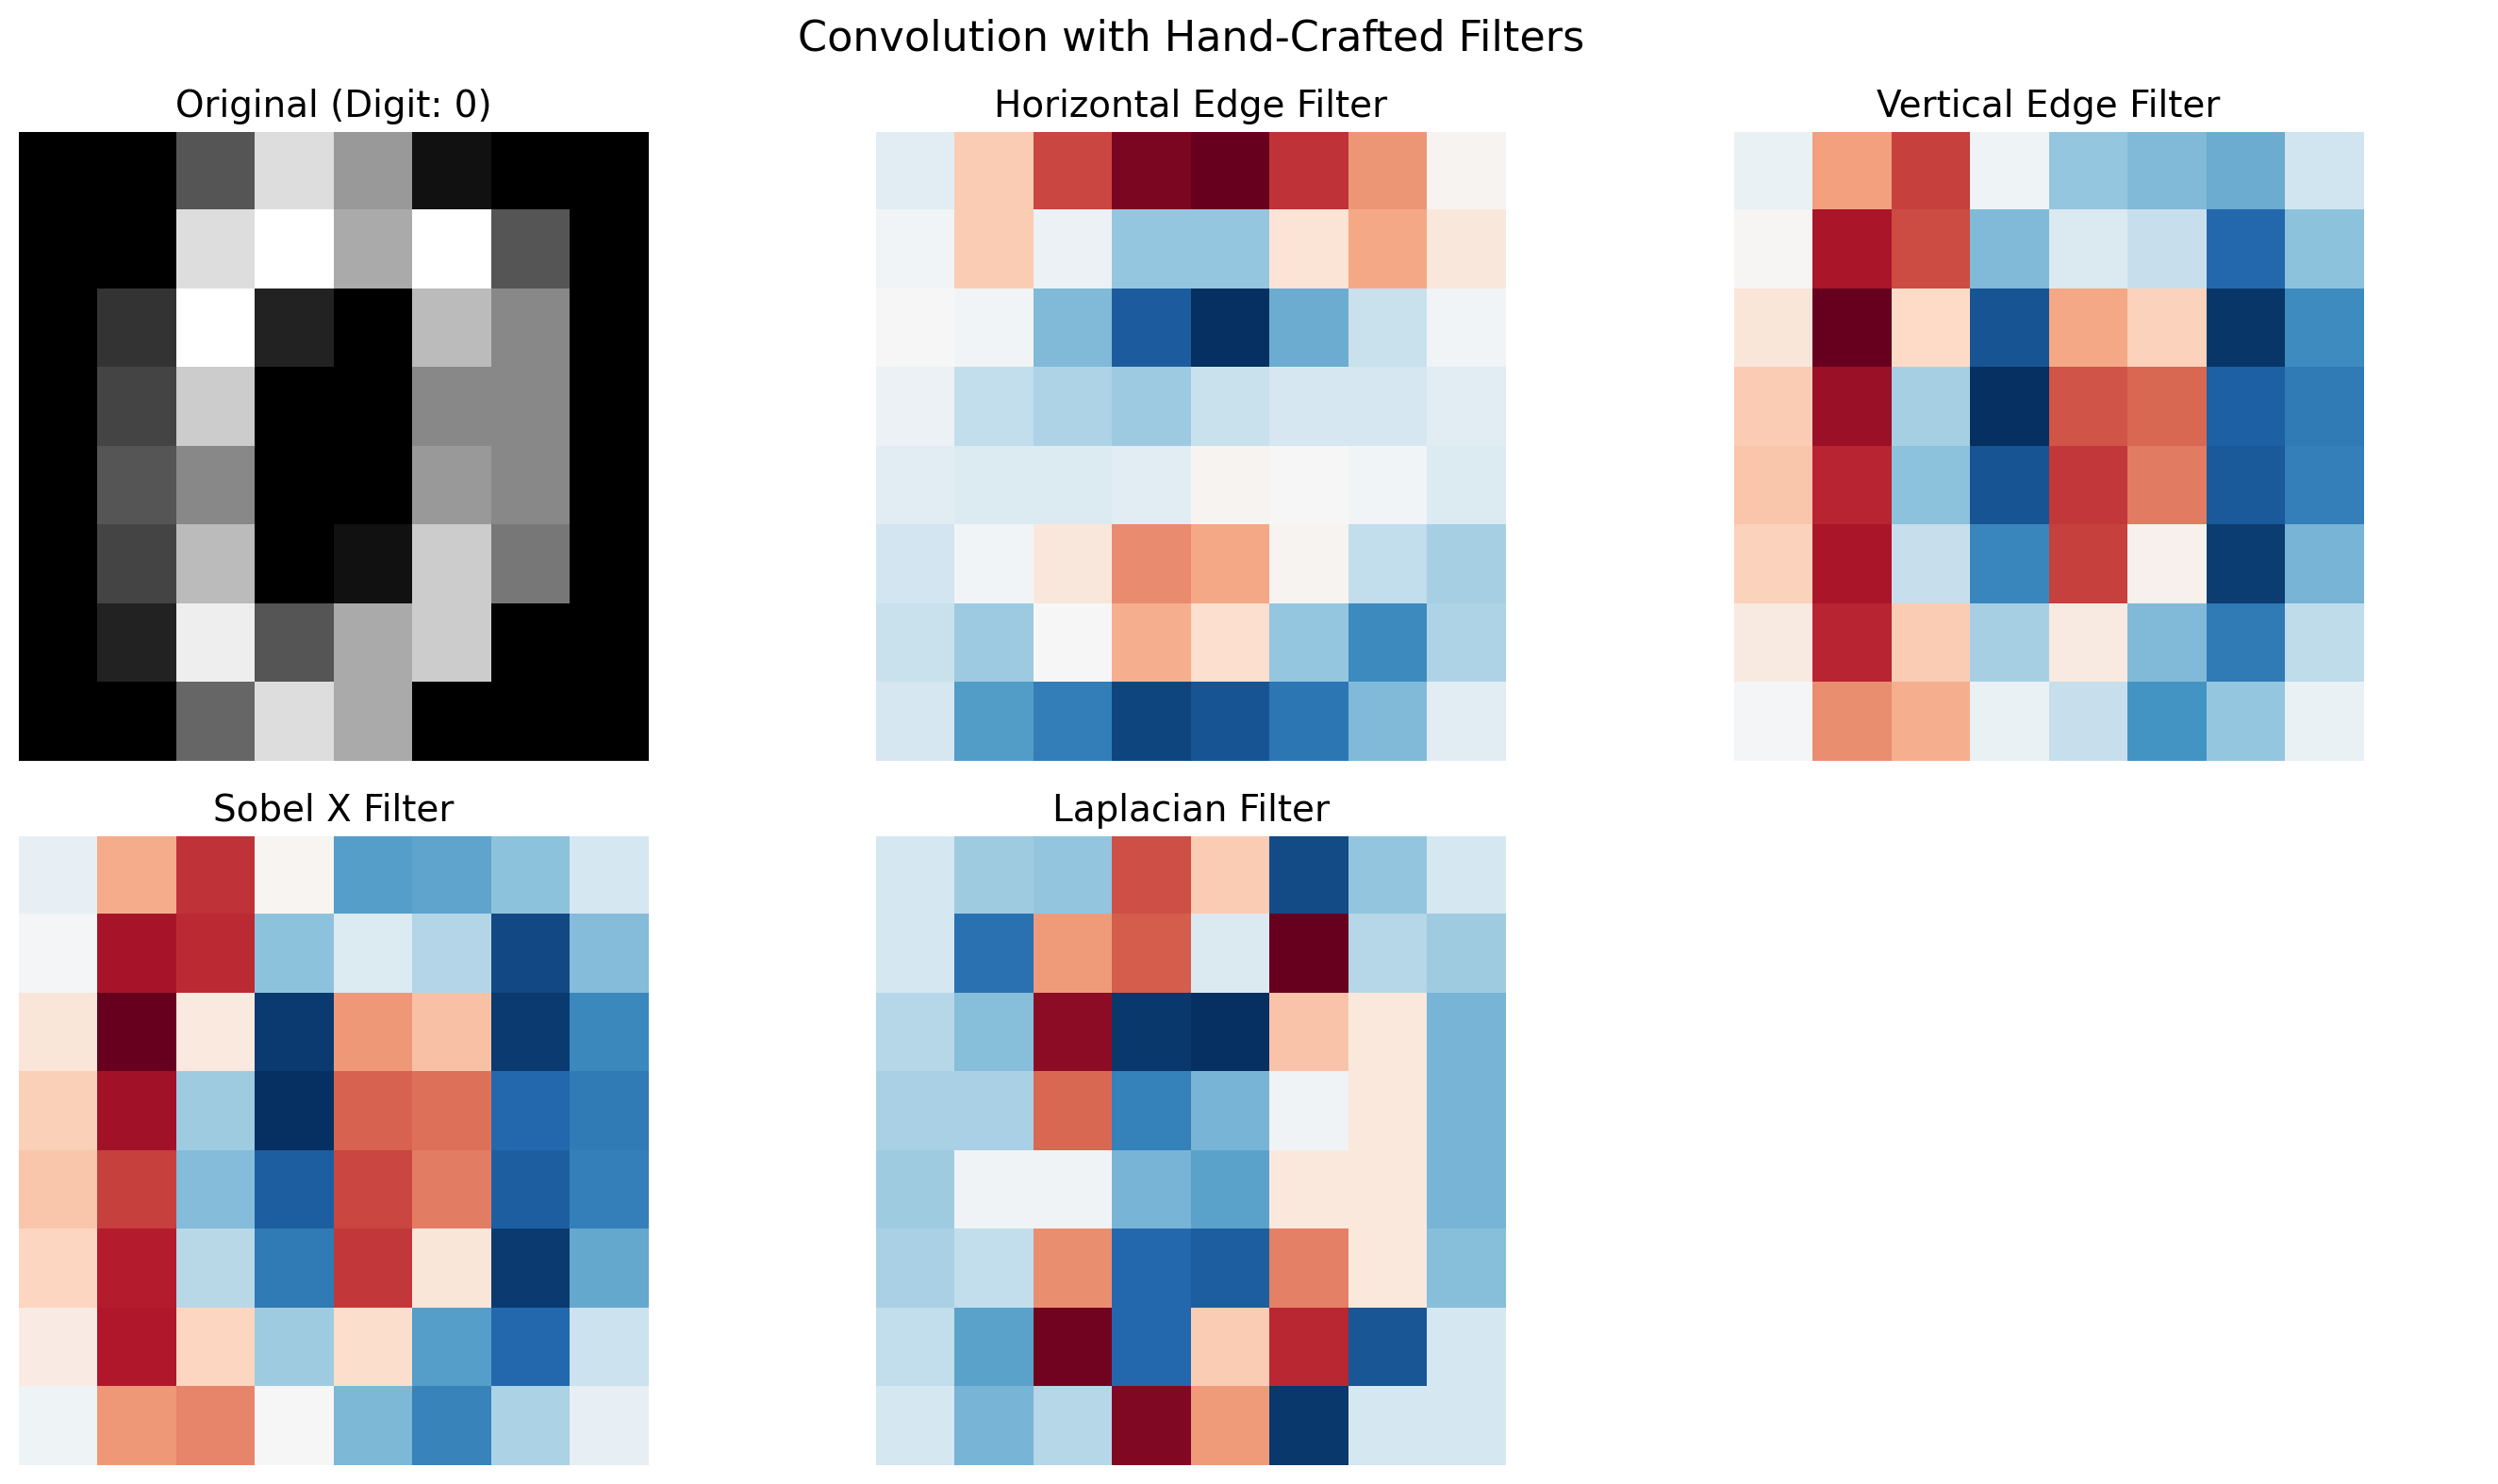


Key Observations:
- Horizontal edge filter highlights horizontal strokes
- Vertical edge filter highlights vertical strokes
- Sobel filter provides gradient magnitude
- Laplacian detects all edges regardless of orientation


In [2]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    Perform 2D convolution on a single-channel image.
    
    Parameters:
    -----------
    image : ndarray, shape (H, W)
        Input image
    kernel : ndarray, shape (k, k)
        Convolutional filter
    stride : int
        Step size for sliding the kernel
    padding : int
        Zero-padding added to image borders
    
    Returns:
    --------
    output : ndarray
        Convolved feature map
    """
    # Add padding if specified
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    
    H, W = image.shape
    k = kernel.shape[0]
    
    # Output dimensions
    out_h = (H - k) // stride + 1
    out_w = (W - k) // stride + 1
    
    output = np.zeros((out_h, out_w))
    
    # Slide kernel across image
    for i in range(out_h):
        for j in range(out_w):
            # Extract patch
            patch = image[i*stride:i*stride+k, j*stride:j*stride+k]
            # Compute dot product (element-wise multiply and sum)
            output[i, j] = np.sum(patch * kernel)
    
    return output


# Load sample images
digits = load_digits()
X = digits.images  # Shape: (n_samples, 8, 8)
y = digits.target

# Select a sample image
sample_idx = 0
sample_image = X[sample_idx]

# Define some classic edge detection kernels
kernels = {
    'Horizontal Edge': np.array([[-1, -1, -1],
                                  [ 0,  0,  0],
                                  [ 1,  1,  1]]),
    'Vertical Edge': np.array([[-1, 0, 1],
                                [-1, 0, 1],
                                [-1, 0, 1]]),
    'Sobel X': np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),
    'Laplacian': np.array([[ 0, -1,  0],
                           [-1,  4, -1],
                           [ 0, -1,  0]])
}

# Apply each kernel and visualize
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Original image
axes[0, 0].imshow(sample_image, cmap='gray')
axes[0, 0].set_title(f'Original (Digit: {y[sample_idx]})')
axes[0, 0].axis('off')

# Apply kernels
for idx, (name, kernel) in enumerate(kernels.items()):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    
    feature_map = conv2d(sample_image, kernel, padding=1)
    
    axes[row, col].imshow(feature_map, cmap='RdBu_r')
    axes[row, col].set_title(f'{name} Filter')
    axes[row, col].axis('off')

# Hide the empty subplot
axes[1, 2].axis('off')

plt.suptitle('Convolution with Hand-Crafted Filters', fontsize=16)
plt.tight_layout()
plt.savefig('image_classification_cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
print("- Horizontal edge filter highlights horizontal strokes")
print("- Vertical edge filter highlights vertical strokes")
print("- Sobel filter provides gradient magnitude")
print("- Laplacian detects all edges regardless of orientation")

## 2. Building CNN Components

Now let's build the components needed for a trainable CNN:

1. **Convolutional Layer**: Learnable filters with forward and backward pass
2. **ReLU Activation**: Non-linearity for learning complex features
3. **Max Pooling**: Downsampling for spatial invariance
4. **Fully Connected Layer**: Classification head

### Architecture Overview

```
Input (8x8x1) 
    -> Conv(4 filters, 3x3) -> ReLU -> (6x6x4)
    -> MaxPool(2x2) -> (3x3x4)
    -> Flatten -> (36)
    -> Dense(10) -> Softmax
    -> Output (10 classes)
```

In [3]:
class ConvLayer:
    """
    Convolutional layer with learnable filters.
    
    Supports forward pass and backpropagation for training.
    """
    
    def __init__(self, num_filters, kernel_size, input_channels=1):
        """
        Initialize convolutional layer.
        
        Parameters:
        -----------
        num_filters : int
            Number of output feature maps
        kernel_size : int
            Size of square filters (e.g., 3 for 3x3)
        input_channels : int
            Number of input channels
        """
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.input_channels = input_channels
        
        # Initialize filters with Xavier/Glorot initialization
        fan_in = input_channels * kernel_size * kernel_size
        fan_out = num_filters * kernel_size * kernel_size
        std = np.sqrt(2.0 / (fan_in + fan_out))
        
        self.filters = np.random.randn(num_filters, input_channels, 
                                        kernel_size, kernel_size) * std
        self.biases = np.zeros(num_filters)
        
        # Cache for backpropagation
        self.last_input = None
        
    def forward(self, x):
        """
        Forward pass through the convolutional layer.
        
        Parameters:
        -----------
        x : ndarray, shape (batch, channels, height, width)
            Input feature maps
        
        Returns:
        --------
        output : ndarray, shape (batch, num_filters, out_h, out_w)
            Output feature maps
        """
        self.last_input = x
        batch_size, in_channels, H, W = x.shape
        k = self.kernel_size
        
        out_h = H - k + 1
        out_w = W - k + 1
        
        output = np.zeros((batch_size, self.num_filters, out_h, out_w))
        
        # For each sample in batch
        for b in range(batch_size):
            # For each filter
            for f in range(self.num_filters):
                # Convolve filter across all input channels
                for c in range(in_channels):
                    output[b, f] += conv2d(x[b, c], self.filters[f, c])
                # Add bias
                output[b, f] += self.biases[f]
        
        return output
    
    def backward(self, d_out, learning_rate):
        """
        Backward pass: compute gradients and update weights.
        
        Parameters:
        -----------
        d_out : ndarray
            Gradient from the next layer
        learning_rate : float
            Learning rate for weight updates
        
        Returns:
        --------
        d_input : ndarray
            Gradient with respect to the input
        """
        x = self.last_input
        batch_size, in_channels, H, W = x.shape
        k = self.kernel_size
        
        # Initialize gradients
        d_filters = np.zeros_like(self.filters)
        d_biases = np.zeros_like(self.biases)
        d_input = np.zeros_like(x)
        
        # Compute gradients
        for b in range(batch_size):
            for f in range(self.num_filters):
                # Bias gradient (sum over spatial dimensions)
                d_biases[f] += np.sum(d_out[b, f])
                
                for c in range(in_channels):
                    # Filter gradient: correlate input with output gradient
                    for i in range(k):
                        for j in range(k):
                            d_filters[f, c, i, j] += np.sum(
                                x[b, c, i:i+d_out.shape[2], j:j+d_out.shape[3]] * d_out[b, f]
                            )
                    
                    # Input gradient: full convolution with flipped filter
                    padded_d_out = np.pad(d_out[b, f], k-1, mode='constant')
                    flipped_filter = np.flip(self.filters[f, c])
                    d_input[b, c] += conv2d(padded_d_out, flipped_filter)
        
        # Average gradients over batch
        d_filters /= batch_size
        d_biases /= batch_size
        
        # Update weights
        self.filters -= learning_rate * d_filters
        self.biases -= learning_rate * d_biases
        
        return d_input


class ReLU:
    """Rectified Linear Unit activation."""
    
    def __init__(self):
        self.mask = None
    
    def forward(self, x):
        self.mask = (x > 0)
        return np.maximum(0, x)
    
    def backward(self, d_out):
        return d_out * self.mask


class MaxPool2D:
    """Max pooling layer for spatial downsampling."""
    
    def __init__(self, pool_size=2):
        self.pool_size = pool_size
        self.last_input = None
        self.max_indices = None
    
    def forward(self, x):
        self.last_input = x
        batch_size, channels, H, W = x.shape
        p = self.pool_size
        
        out_h = H // p
        out_w = W // p
        
        output = np.zeros((batch_size, channels, out_h, out_w))
        self.max_indices = np.zeros_like(output, dtype=int)
        
        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        pool_region = x[b, c, i*p:(i+1)*p, j*p:(j+1)*p]
                        output[b, c, i, j] = np.max(pool_region)
                        self.max_indices[b, c, i, j] = np.argmax(pool_region)
        
        return output
    
    def backward(self, d_out):
        x = self.last_input
        batch_size, channels, H, W = x.shape
        p = self.pool_size
        
        d_input = np.zeros_like(x)
        out_h, out_w = d_out.shape[2], d_out.shape[3]
        
        for b in range(batch_size):
            for c in range(channels):
                for i in range(out_h):
                    for j in range(out_w):
                        idx = self.max_indices[b, c, i, j]
                        i_max, j_max = idx // p, idx % p
                        d_input[b, c, i*p + i_max, j*p + j_max] = d_out[b, c, i, j]
        
        return d_input


class Flatten:
    """Flatten layer to convert feature maps to 1D vector."""
    
    def __init__(self):
        self.original_shape = None
    
    def forward(self, x):
        self.original_shape = x.shape
        return x.reshape(x.shape[0], -1)
    
    def backward(self, d_out):
        return d_out.reshape(self.original_shape)


class Dense:
    """Fully connected layer."""
    
    def __init__(self, input_size, output_size):
        std = np.sqrt(2.0 / (input_size + output_size))
        self.weights = np.random.randn(input_size, output_size) * std
        self.biases = np.zeros(output_size)
        self.last_input = None
    
    def forward(self, x):
        self.last_input = x
        return x @ self.weights + self.biases
    
    def backward(self, d_out, learning_rate):
        batch_size = self.last_input.shape[0]
        
        d_weights = self.last_input.T @ d_out / batch_size
        d_biases = np.mean(d_out, axis=0)
        d_input = d_out @ self.weights.T
        
        self.weights -= learning_rate * d_weights
        self.biases -= learning_rate * d_biases
        
        return d_input


def softmax(x):
    """Numerically stable softmax."""
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def cross_entropy_loss(predictions, targets):
    """Cross-entropy loss for classification."""
    batch_size = predictions.shape[0]
    # Add small epsilon for numerical stability
    log_probs = -np.log(predictions[range(batch_size), targets] + 1e-10)
    return np.mean(log_probs)


print("CNN Components Implemented:")
print("  - ConvLayer: Learnable convolutional filters")
print("  - ReLU: Non-linear activation")
print("  - MaxPool2D: Spatial downsampling")
print("  - Flatten: Reshape for dense layers")
print("  - Dense: Fully connected classification head")
print("  - Softmax + Cross-Entropy: Classification loss")

CNN Components Implemented:
  - ConvLayer: Learnable convolutional filters
  - ReLU: Non-linear activation
  - MaxPool2D: Spatial downsampling
  - Flatten: Reshape for dense layers
  - Dense: Fully connected classification head
  - Softmax + Cross-Entropy: Classification loss


## 3. Building and Training the CNN

Now we'll assemble these components into a complete CNN and train it on the digits dataset.

### Training Process

1. **Forward Pass**: Input -> Conv -> ReLU -> Pool -> Flatten -> Dense -> Softmax
2. **Compute Loss**: Cross-entropy between predictions and true labels
3. **Backward Pass**: Propagate gradients through all layers
4. **Update Weights**: Adjust filters and dense weights using gradients

In [4]:
class SimpleCNN:
    """
    Simple CNN for image classification.
    
    Architecture:
    Input (8x8x1) -> Conv(4, 3x3) -> ReLU -> MaxPool(2x2) -> Flatten -> Dense(10)
    """
    
    def __init__(self):
        # Convolutional layers
        self.conv1 = ConvLayer(num_filters=4, kernel_size=3, input_channels=1)
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(pool_size=2)
        
        # Flatten and dense
        self.flatten = Flatten()
        # After conv: (8-3+1) = 6, after pool: 6/2 = 3
        # Feature map size: 3 * 3 * 4 = 36
        self.dense = Dense(input_size=36, output_size=10)
        
        # Training history
        self.loss_history = []
        self.accuracy_history = []
        
    def forward(self, x):
        """Forward pass through the network."""
        # Reshape input: (batch, H, W) -> (batch, 1, H, W)
        if x.ndim == 3:
            x = x[:, np.newaxis, :, :]
        
        # Conv block
        out = self.conv1.forward(x)
        out = self.relu1.forward(out)
        out = self.pool1.forward(out)
        
        # Classification head
        out = self.flatten.forward(out)
        logits = self.dense.forward(out)
        probs = softmax(logits)
        
        return probs
    
    def backward(self, predictions, targets, learning_rate):
        """Backward pass and weight update."""
        batch_size = predictions.shape[0]
        
        # Gradient of softmax + cross-entropy
        d_logits = predictions.copy()
        d_logits[range(batch_size), targets] -= 1
        
        # Backpropagate through dense layer
        d_flat = self.dense.backward(d_logits, learning_rate)
        
        # Backpropagate through flatten
        d_pool = self.flatten.backward(d_flat)
        
        # Backpropagate through pooling and conv
        d_relu = self.pool1.backward(d_pool)
        d_conv = self.relu1.backward(d_relu)
        self.conv1.backward(d_conv, learning_rate)
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50, 
              batch_size=32, learning_rate=0.01):
        """Train the CNN."""
        n_samples = X_train.shape[0]
        n_batches = n_samples // batch_size
        
        print(f"Training CNN for {epochs} epochs...")
        print(f"  Batch size: {batch_size}, Batches per epoch: {n_batches}")
        print("-" * 50)
        
        for epoch in range(epochs):
            # Shuffle training data
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            epoch_loss = 0
            
            for batch in range(n_batches):
                start = batch * batch_size
                end = start + batch_size
                
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                
                # Forward pass
                predictions = self.forward(X_batch)
                
                # Compute loss
                loss = cross_entropy_loss(predictions, y_batch)
                epoch_loss += loss
                
                # Backward pass and update
                self.backward(predictions, y_batch, learning_rate)
            
            # Compute validation accuracy
            val_preds = self.forward(X_val)
            val_acc = np.mean(np.argmax(val_preds, axis=1) == y_val)
            
            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)
            self.accuracy_history.append(val_acc)
            
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1:3d}: Loss = {avg_loss:.4f}, Val Accuracy = {val_acc:.4f}")
        
        print("-" * 50)
        print(f"Final validation accuracy: {self.accuracy_history[-1]:.4f}")
        
        return self.loss_history, self.accuracy_history


# Prepare data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize pixel values
X_train = X_train / 16.0
X_test = X_test / 16.0

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train[0].shape}")

# Create and train CNN (reduced epochs for faster execution)
cnn = SimpleCNN()
loss_history, acc_history = cnn.train(
    X_train, y_train, X_test, y_test,
    epochs=30, batch_size=32, learning_rate=0.05  # Fewer epochs, higher LR
)

Training samples: 1437
Test samples: 360
Image shape: (8, 8)
Training CNN for 30 epochs...
  Batch size: 32, Batches per epoch: 44
--------------------------------------------------


Epoch   5: Loss = 1.3465, Val Accuracy = 0.7500


Epoch  10: Loss = 0.4975, Val Accuracy = 0.8778


Epoch  15: Loss = 0.3244, Val Accuracy = 0.9250


Epoch  20: Loss = 0.2438, Val Accuracy = 0.9167


Epoch  25: Loss = 0.2068, Val Accuracy = 0.9472


Epoch  30: Loss = 0.1765, Val Accuracy = 0.9417
--------------------------------------------------
Final validation accuracy: 0.9417


## 4. Visualizing Training and Learned Features

Let's examine what our CNN has learned:

1. **Training Curves**: Loss and accuracy over epochs
2. **Learned Filters**: What patterns do the convolutional filters detect?
3. **Feature Maps**: How are different digits processed by the network?
4. **Predictions**: Sample classifications with confidence

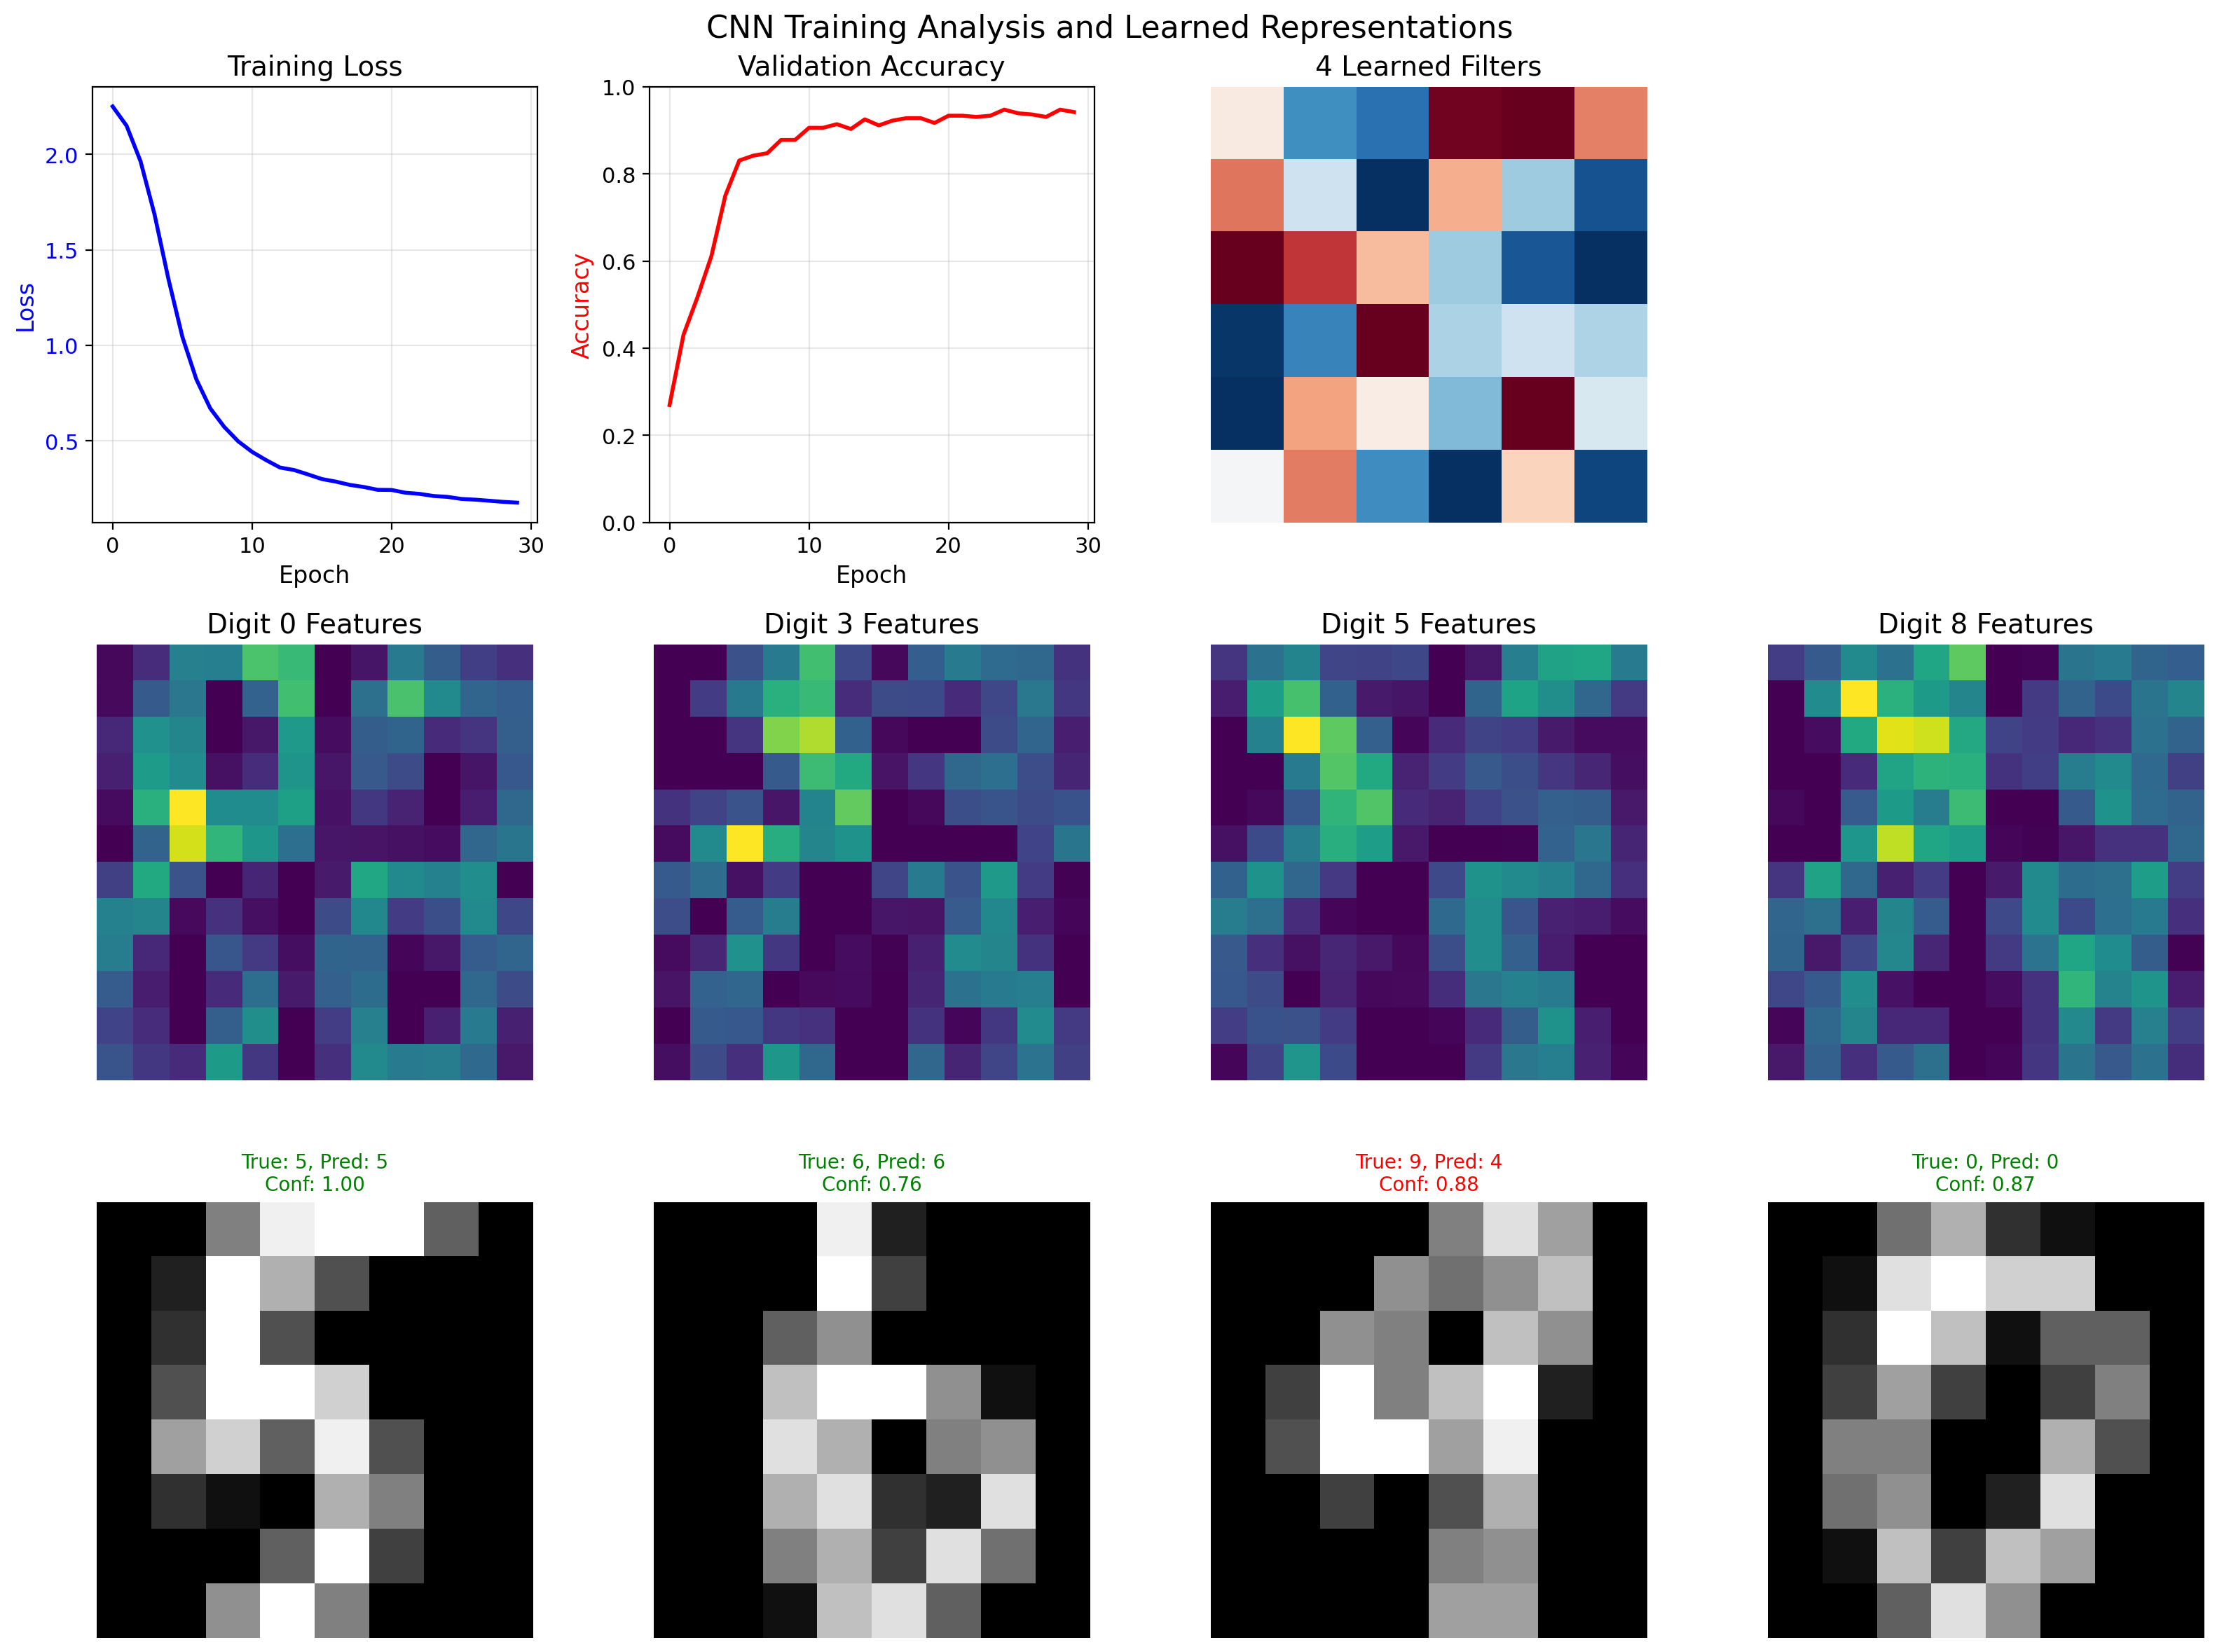


Final Test Accuracy: 0.9417


In [5]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 1. Training curves
ax1 = fig.add_subplot(3, 4, 1)
ax1.plot(loss_history, 'b-', linewidth=2, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(3, 4, 2)
ax2.plot(acc_history, 'r-', linewidth=2, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy', color='r')
ax2.set_ylim(0, 1)
ax2.set_title('Validation Accuracy')
ax2.grid(True, alpha=0.3)

# 2. Learned filters
filters = cnn.conv1.filters[:, 0, :, :]  # Shape: (4, 3, 3)

ax3 = fig.add_subplot(3, 4, 3)
filter_mosaic = np.zeros((6, 6))
filter_mosaic[:3, :3] = (filters[0] - filters[0].min()) / (filters[0].max() - filters[0].min() + 1e-8)
filter_mosaic[:3, 3:] = (filters[1] - filters[1].min()) / (filters[1].max() - filters[1].min() + 1e-8)
filter_mosaic[3:, :3] = (filters[2] - filters[2].min()) / (filters[2].max() - filters[2].min() + 1e-8)
filter_mosaic[3:, 3:] = (filters[3] - filters[3].min()) / (filters[3].max() - filters[3].min() + 1e-8)
ax3.imshow(filter_mosaic, cmap='RdBu_r')
ax3.set_title('4 Learned Filters')
ax3.axis('off')

# 3. Feature maps for sample digits
sample_digits = [0, 3, 5, 8]  # Select diverse digits
for idx, digit in enumerate(sample_digits):
    # Find a sample of this digit
    sample_idx = np.where(y_test == digit)[0][0]
    sample = X_test[sample_idx:sample_idx+1]
    
    # Get feature maps after conv
    sample_4d = sample[:, np.newaxis, :, :]
    conv_out = cnn.conv1.forward(sample_4d)
    relu_out = cnn.relu1.forward(conv_out)
    
    ax = fig.add_subplot(3, 4, 5 + idx)
    
    # Create feature map montage
    fmap_grid = np.zeros((6*2, 6*2))
    for f in range(4):
        r, c = f // 2, f % 2
        fmap_grid[r*6:(r+1)*6, c*6:(c+1)*6] = relu_out[0, f]
    
    ax.imshow(fmap_grid, cmap='viridis')
    ax.set_title(f'Digit {digit} Features')
    ax.axis('off')

# 4. Sample predictions
np.random.seed(123)
sample_indices = np.random.choice(len(X_test), 4, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    ax = fig.add_subplot(3, 4, 9 + idx)
    
    sample = X_test[sample_idx:sample_idx+1]
    true_label = y_test[sample_idx]
    
    probs = cnn.forward(sample)[0]
    pred_label = np.argmax(probs)
    confidence = probs[pred_label]
    
    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(sample[0], cmap='gray')
    ax.set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2f}', 
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('CNN Training Analysis and Learned Representations', fontsize=16)
plt.tight_layout()
plt.savefig('image_classification_cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Final test accuracy
test_preds = cnn.forward(X_test)
test_acc = np.mean(np.argmax(test_preds, axis=1) == y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

## 5. Understanding What CNNs Learn

Let's visualize the complete processing pipeline for a single image, showing how the network transforms raw pixels into class probabilities.

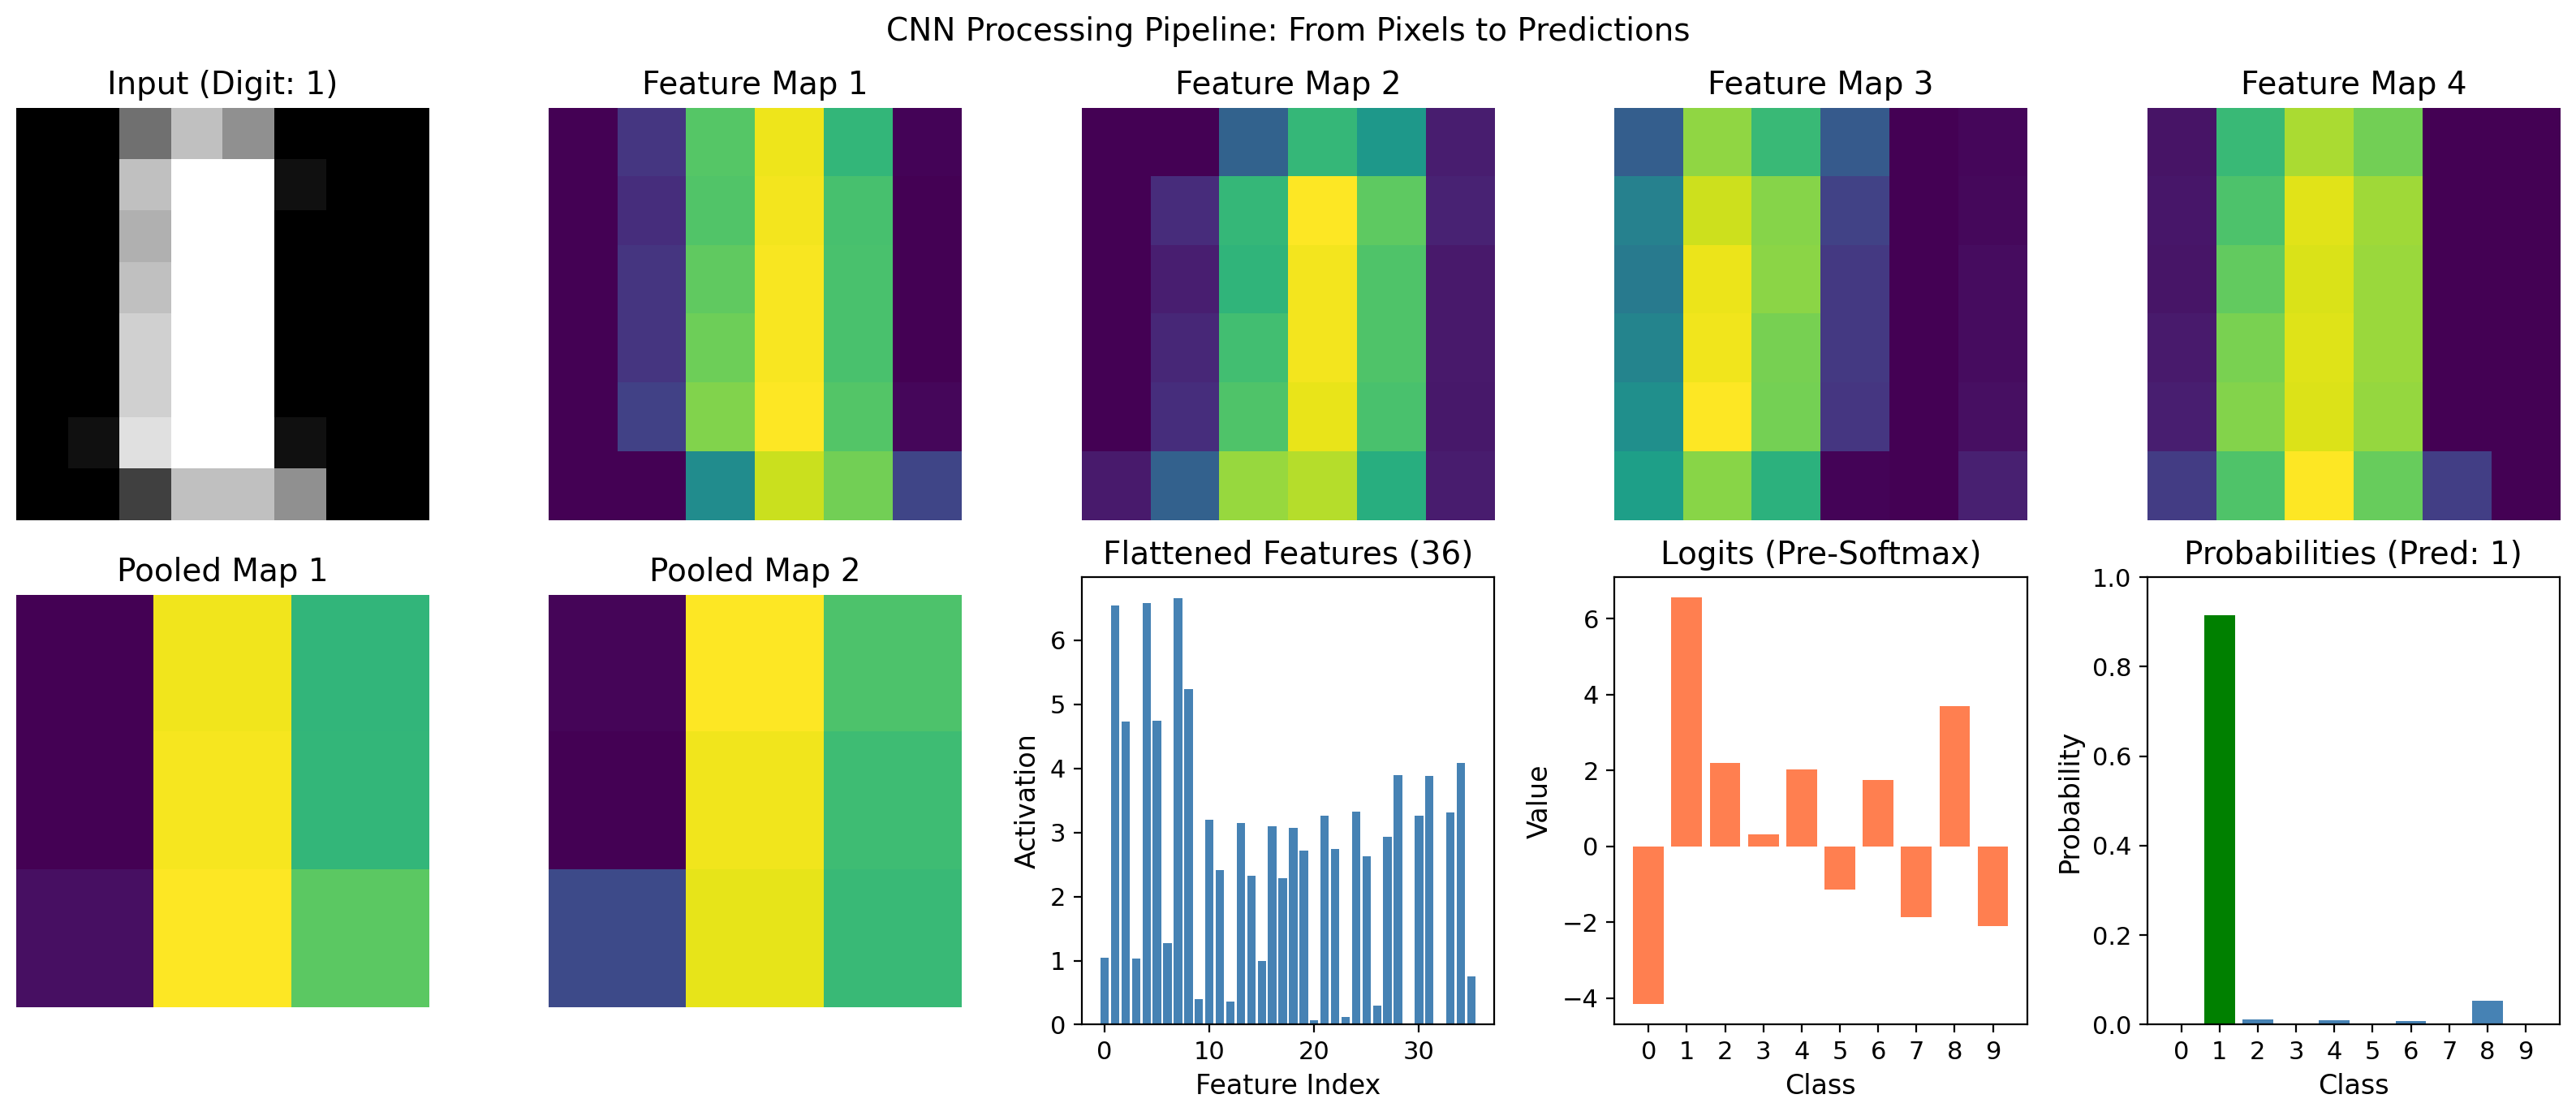


Pipeline Summary:
  Input shape: (1, 8, 8) -> Convolved: (1, 4, 6, 6)
  After ReLU: (1, 4, 6, 6) -> Pooled: (1, 4, 3, 3)
  Flattened: (1, 36) -> Logits: (1, 10)
  Probabilities: (1, 10)

  Predicted class: 1 with confidence 0.9155
  True class: 1


In [6]:
# Detailed pipeline visualization
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Select a sample
sample_idx = 42
sample = X_test[sample_idx:sample_idx+1]
true_label = y_test[sample_idx]

# Forward pass with intermediate outputs
sample_4d = sample[:, np.newaxis, :, :]
conv_out = cnn.conv1.forward(sample_4d)
relu_out = cnn.relu1.forward(conv_out)
pool_out = cnn.pool1.forward(relu_out)
flat_out = cnn.flatten.forward(pool_out)
logits = cnn.dense.forward(flat_out)
probs = softmax(logits)

# Row 1: Input and feature maps
axes[0, 0].imshow(sample[0], cmap='gray')
axes[0, 0].set_title(f'Input (Digit: {true_label})')
axes[0, 0].axis('off')

for i in range(4):
    axes[0, i+1].imshow(relu_out[0, i], cmap='viridis')
    axes[0, i+1].set_title(f'Feature Map {i+1}')
    axes[0, i+1].axis('off')

# Row 2: Pooled features and classification
axes[1, 0].imshow(pool_out[0, 0], cmap='viridis')
axes[1, 0].set_title('Pooled Map 1')
axes[1, 0].axis('off')

axes[1, 1].imshow(pool_out[0, 1], cmap='viridis')
axes[1, 1].set_title('Pooled Map 2')
axes[1, 1].axis('off')

# Flattened representation as bar chart
axes[1, 2].bar(range(len(flat_out[0])), flat_out[0], color='steelblue')
axes[1, 2].set_title('Flattened Features (36)')
axes[1, 2].set_xlabel('Feature Index')
axes[1, 2].set_ylabel('Activation')

# Logits
axes[1, 3].bar(range(10), logits[0], color='coral')
axes[1, 3].set_title('Logits (Pre-Softmax)')
axes[1, 3].set_xlabel('Class')
axes[1, 3].set_ylabel('Value')
axes[1, 3].set_xticks(range(10))

# Final probabilities
colors = ['green' if i == true_label else 'steelblue' for i in range(10)]
axes[1, 4].bar(range(10), probs[0], color=colors)
axes[1, 4].set_title(f'Probabilities (Pred: {np.argmax(probs)})')
axes[1, 4].set_xlabel('Class')
axes[1, 4].set_ylabel('Probability')
axes[1, 4].set_xticks(range(10))
axes[1, 4].set_ylim(0, 1)

plt.suptitle('CNN Processing Pipeline: From Pixels to Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('image_classification_cnn_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPipeline Summary:")
print(f"  Input shape: {sample.shape} -> Convolved: {conv_out.shape}")
print(f"  After ReLU: {relu_out.shape} -> Pooled: {pool_out.shape}")
print(f"  Flattened: {flat_out.shape} -> Logits: {logits.shape}")
print(f"  Probabilities: {probs.shape}")
print(f"\n  Predicted class: {np.argmax(probs)} with confidence {probs[0, np.argmax(probs)]:.4f}")
print(f"  True class: {true_label}")

## 6. Confusion Matrix and Per-Class Performance

Let's analyze which digits the CNN classifies correctly and where it makes mistakes.

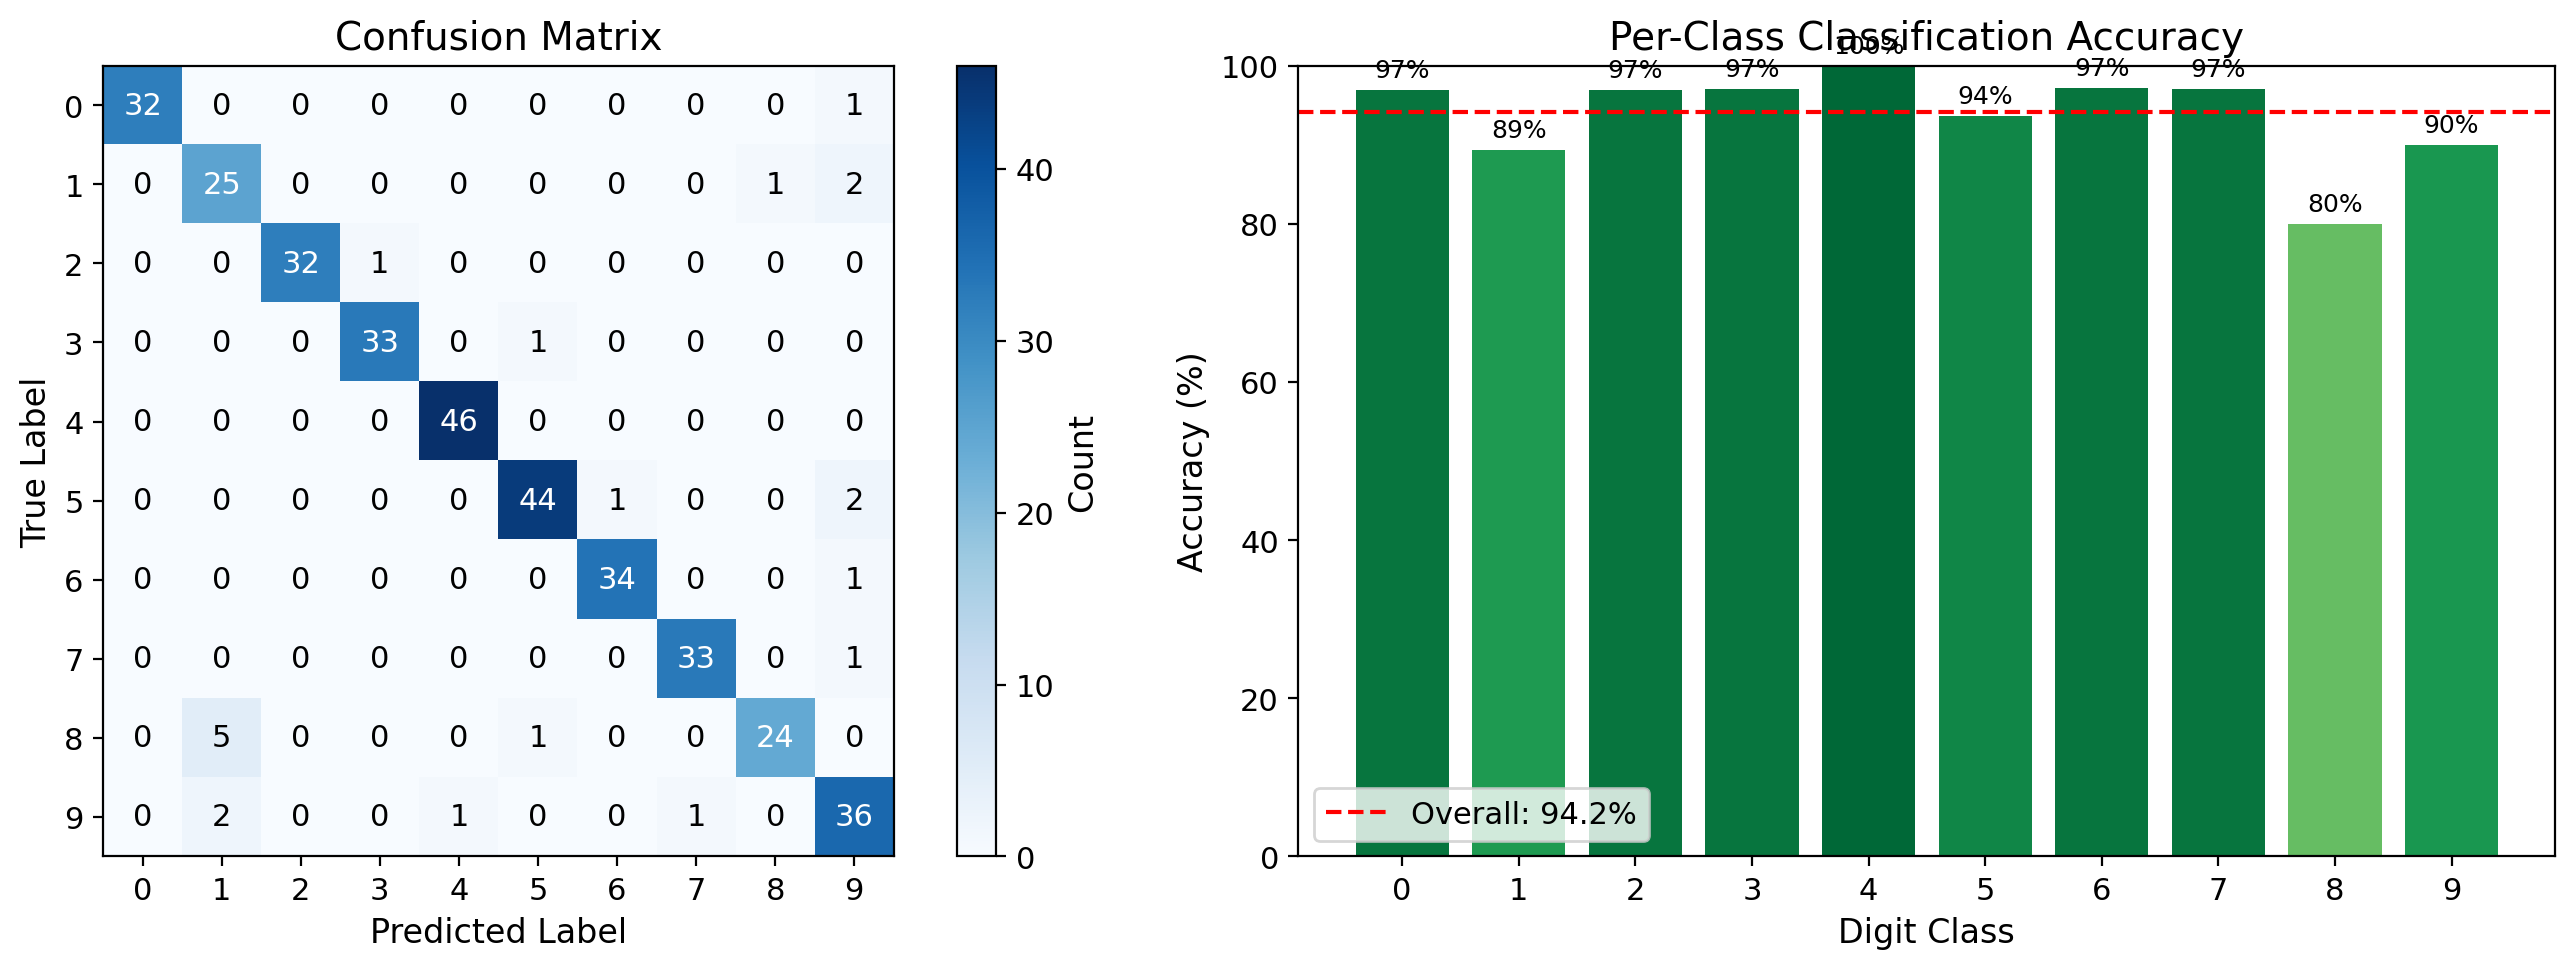


Per-Class Performance:
  Digit 0:  97.0% (33 samples)
  Digit 1:  89.3% (28 samples)
  Digit 2:  97.0% (33 samples)
  Digit 3:  97.1% (34 samples)
  Digit 4: 100.0% (46 samples)
  Digit 5:  93.6% (47 samples)
  Digit 6:  97.1% (35 samples)
  Digit 7:  97.1% (34 samples)
  Digit 8:  80.0% (30 samples)
  Digit 9:  90.0% (40 samples)

Overall Test Accuracy: 94.17%

Most Common Misclassifications:
  8 -> 1: 5 times
  9 -> 1: 2 times
  5 -> 9: 2 times
  1 -> 9: 2 times
  9 -> 7: 1 times


In [7]:
# Compute predictions on test set
test_probs = cnn.forward(X_test)
test_preds = np.argmax(test_probs, axis=1)

# Confusion matrix
confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, test_preds):
    confusion[true, pred] += 1

# Per-class accuracy
per_class_acc = np.diag(confusion) / confusion.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
im = axes[0].imshow(confusion, cmap='Blues')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))

# Add text annotations
for i in range(10):
    for j in range(10):
        color = 'white' if confusion[i, j] > confusion.max()/2 else 'black'
        axes[0].text(j, i, confusion[i, j], ha='center', va='center', color=color)

plt.colorbar(im, ax=axes[0], label='Count')

# Per-class accuracy bar chart
colors = plt.cm.RdYlGn(per_class_acc)
bars = axes[1].bar(range(10), per_class_acc * 100, color=colors)
axes[1].axhline(y=test_acc * 100, color='red', linestyle='--', 
                label=f'Overall: {test_acc*100:.1f}%')
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Class Classification Accuracy')
axes[1].set_xticks(range(10))
axes[1].set_ylim(0, 100)
axes[1].legend()

# Add percentage labels on bars
for i, (bar, acc) in enumerate(zip(bars, per_class_acc)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc*100:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('image_classification_cnn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Class Performance:")
for digit in range(10):
    print(f"  Digit {digit}: {per_class_acc[digit]*100:5.1f}% ({np.sum(confusion[digit])} samples)")
    
print(f"\nOverall Test Accuracy: {test_acc*100:.2f}%")

# Find most common mistakes
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j and confusion[i, j] > 0:
            mistakes.append((confusion[i, j], i, j))

mistakes.sort(reverse=True)
print("\nMost Common Misclassifications:")
for count, true, pred in mistakes[:5]:
    print(f"  {true} -> {pred}: {count} times")

## Key Takeaways

### What We Built
A complete CNN implementation from scratch including:
- **Convolutional layers** with learnable filters
- **Backpropagation** through all spatial operations
- **Training loop** with mini-batch gradient descent

### What We Learned
1. **Convolution extracts local features**: The learned 3x3 filters detect edges, corners, and simple patterns
2. **Feature hierarchy emerges**: Early layers detect simple patterns; later processing combines them
3. **Spatial invariance**: Pooling helps the network recognize patterns regardless of exact position
4. **End-to-end learning**: All filters are learned jointly to optimize classification

### Limitations of This Simple CNN
- Only one convolutional layer (real CNNs have many)
- Small 8x8 images (real images are much larger)
- No data augmentation (rotation, scaling would help)
- No batch normalization or dropout (for regularization)

### Next Steps
To build on this foundation:
1. Add more convolutional layers for deeper feature hierarchies
2. Implement batch normalization for training stability
3. Add dropout for regularization
4. Try on larger datasets (MNIST, CIFAR-10)
5. Use GPU acceleration for faster training

---

**Key Equations:**

Convolution: $y_{i,j} = \sum_{m,n} x_{i+m,j+n} \cdot w_{m,n} + b$

ReLU: $f(x) = \max(0, x)$

Max Pooling: $y_{i,j} = \max_{m,n \in \text{pool}} x_{i \cdot s + m, j \cdot s + n}$

Cross-Entropy: $L = -\sum_c y_c \log(\hat{y}_c)$